In [1]:
# ==================== INSTALL & IMPORTS ====================
%pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


Note: you may need to restart the kernel to use updated packages.


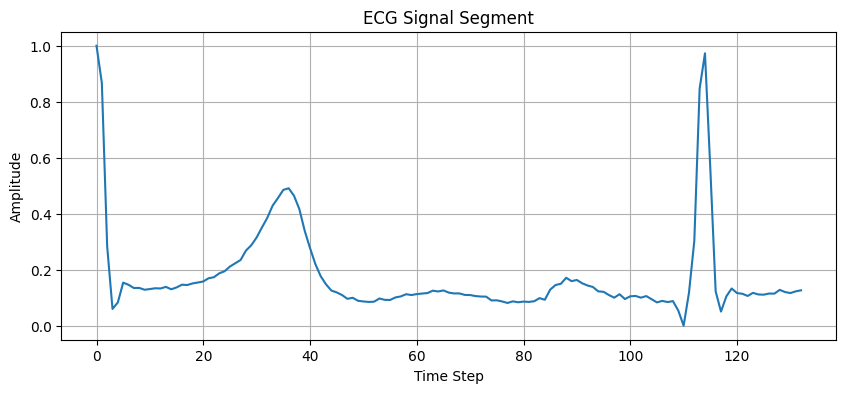

In [2]:
# ==================== SELECT ECG SEGMENT ====================
%run CleanData.ipynb
# Use the first ECG row (adjust index as needed)
ecg_series = X_test.iloc[0] if isinstance(X_test, pd.DataFrame) else pd.Series(X_test[0].flatten())

# Plot original ECG segment
plt.figure(figsize=(10, 4))
plt.plot(ecg_series)
plt.title("ECG Signal Segment")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [3]:
# ==================== FIT SARIMA MODEL ====================
model = SARIMAX(ecg_series, order=(2, 1, 2), seasonal_order=(1, 1, 1, 30))
sarima_result = model.fit(disp=False)


c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [4]:
# ==================== COMPUTE RESIDUALS ====================
predicted = sarima_result.predict(start=0, end=len(ecg_series)-1)
residuals = ecg_series - predicted

# Set threshold for anomaly detection (e.g., 3 std deviations)
threshold = 3 * np.std(residuals)
anomalies = np.abs(residuals) > threshold


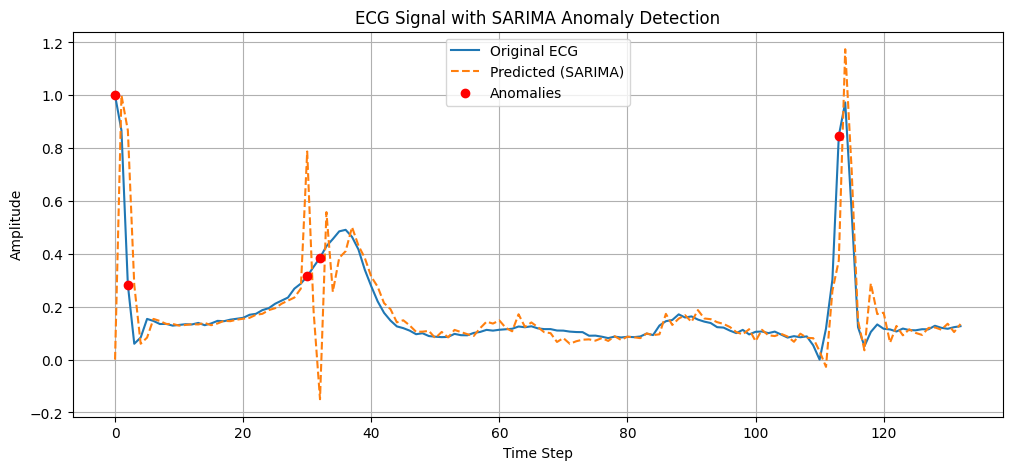

In [5]:
# ==================== PLOT ANOMALIES ====================
plt.figure(figsize=(12, 5))
plt.plot(ecg_series, label="Original ECG")
plt.plot(predicted, label="Predicted (SARIMA)", linestyle='--')
plt.scatter(
    np.where(anomalies)[0],
    ecg_series[anomalies],
    color="red",
    label="Anomalies",
    zorder=10
)
plt.title("ECG Signal with SARIMA Anomaly Detection")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# ==================== ANOMALY SUMMARY ====================
print(f"Detected {anomalies.sum()} anomalies out of {len(ecg_series)} time steps.")
print("Anomaly indices:", np.where(anomalies)[0].tolist())


Detected 5 anomalies out of 133 time steps.
Anomaly indices: [0, 2, 30, 32, 113]
